# 02 - Kaplan-Meier curves and the log-rank test

In this notebook the event is **activation**, not churn.

That means the survival curve answers:

> What fraction of users have not activated yet by day t?

This is a useful trick. Survival analysis is not only for bad events. It is for any event where timing matters.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
activation = pd.read_csv(DATA_DIR / "product_activation_survival.csv")
activation.head()

,user_id,onboarding_path,signup_device,team_size,invited_teammates,first_week_actions,time_to_activation_days,activated_observed,followup_days
0,U0001,Guided Setup,Desktop,department,4,6,5,1,41
1,U0002,Guided Setup,Mobile,small_team,1,2,30,0,30
2,U0003,Self Serve,Mobile,solo,0,2,1,1,28
3,U0004,Self Serve,Mobile,solo,0,1,10,1,45
4,U0005,Self Serve,Mobile,solo,0,3,12,1,36


In [3]:
activation.describe(include="all").T[["count", "unique", "top", "mean", "min", "max"]]

,count,unique,top,mean,min,max
user_id,900,900,U0001,NaN,NaN,NaN
onboarding_path,900,3,Self Serve,NaN,NaN,NaN
signup_device,900,2,Desktop,NaN,NaN,NaN
team_size,900,3,solo,NaN,NaN,NaN
invited_teammates,900.0,NaN,NaN,1.824444,0.0,13.0
first_week_actions,900.0,NaN,NaN,5.16,0.0,15.0
time_to_activation_days,900.0,NaN,NaN,11.564444,1.0,45.0
activated_observed,900.0,NaN,NaN,0.931111,0.0,1.0
followup_days,900.0,NaN,NaN,36.388889,28.0,45.0


Two details about these columns are worth pausing on:

- `followup_days` is how long we could observe each user. For every censored row (`activated_observed = 0`), `time_to_activation_days` equals `followup_days` exactly: the observation window ended before activation did. That is administrative censoring, the benign kind (notebook 01 covers why that matters).
- Durations are day-ceiled integers, so many users share the same duration. Heavy ties are normal in product data, and both Kaplan-Meier and the log-rank test handle ties without complaint.

## Overall activation curve

The table below shows `S(14) = 0.301`. Read it as:

> About 30% of users have not activated by day 14.

The cumulative event curve is `1 - S(t)`, or the fraction activated by time `t`. The shaded band around each curve is a 95% confidence interval, computed from Greenwood's variance formula.

One forward-looking footnote on `1 - S(t)`: with a single event type and independent censoring, it is the cumulative incidence of activation, exactly as read. But when a competing event can remove users first (say, account deletion before activation), `1 - KM` overstates incidence - a classic misuse to watch for.

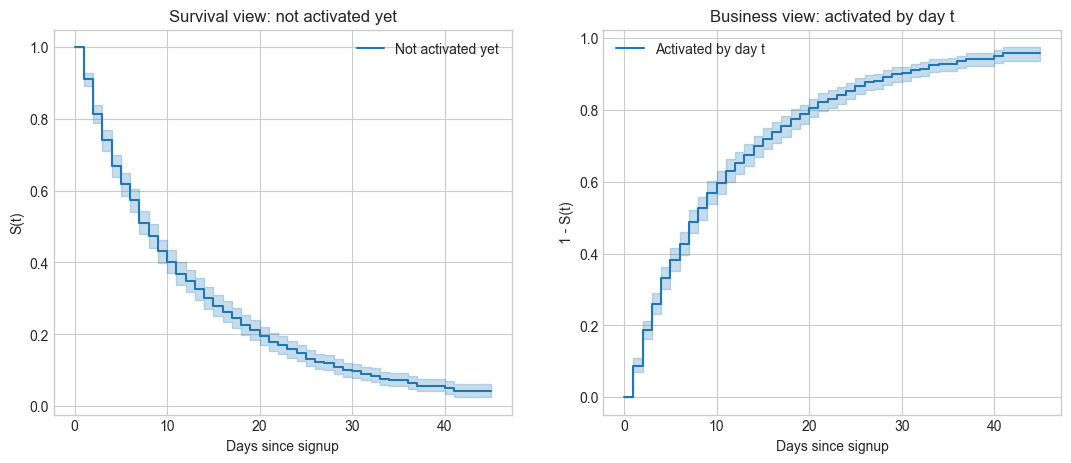

Overall median time to activation: 8 days (95% CI 7-9)


,day,not_activated_yet,activated_by_day
0,7,0.511,0.489
1,14,0.301,0.699
2,21,0.178,0.822
3,30,0.098,0.902


In [4]:
from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times

kmf = KaplanMeierFitter()
kmf.fit(
    activation["time_to_activation_days"],
    event_observed=activation["activated_observed"],
    label="Not activated yet",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
kmf.plot_survival_function(ax=axes[0])
axes[0].set_title("Survival view: not activated yet")
axes[0].set_xlabel("Days since signup")
axes[0].set_ylabel("S(t)")

kmf.plot_cumulative_density(ax=axes[1], label="Activated by day t")
axes[1].set_title("Business view: activated by day t")
axes[1].set_xlabel("Days since signup")
axes[1].set_ylabel("1 - S(t)")
plt.show()

median_ci = median_survival_times(kmf.confidence_interval_)
print(
    f"Overall median time to activation: {kmf.median_survival_time_:.0f} days "
    f"(95% CI {median_ci.iloc[0, 0]:.0f}-{median_ci.iloc[0, 1]:.0f})"
)

pd.DataFrame({
    "day": [7, 14, 21, 30],
    "not_activated_yet": kmf.survival_function_at_times([7, 14, 21, 30]).values.round(3),
    "activated_by_day": (1 - kmf.survival_function_at_times([7, 14, 21, 30]).values).round(3),
})

## Segment curves

A single curve tells us the average story. Segment curves ask whether different groups travel through time differently.

Here we compare onboarding paths. This is not a causal claim yet. It is a descriptive survival comparison. In real data, users *select into* onboarding paths: bigger teams and higher-intent buyers get routed to concierge treatment, plan tier gates who sees what. So an unadjusted KM gap mixes the effect of the path with the effect of who ended up on it. Notebook 03 starts untangling that.

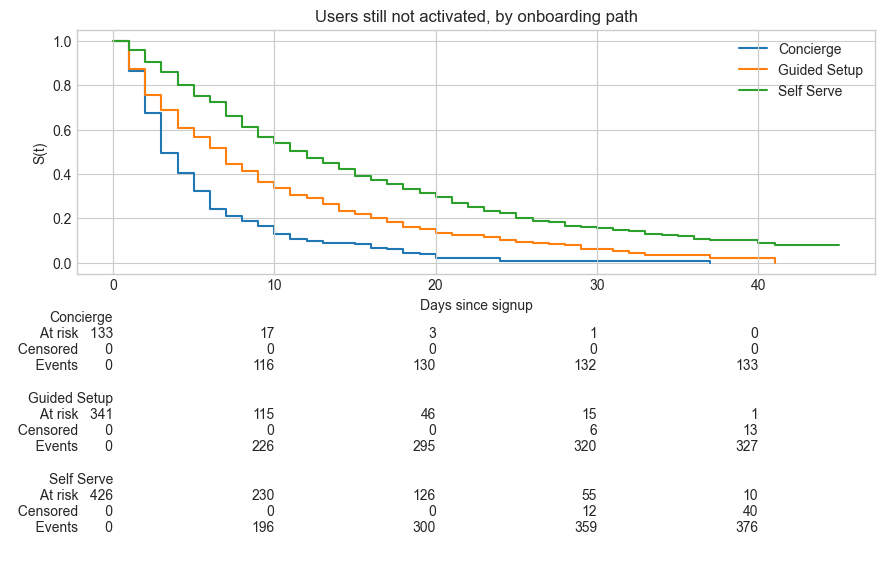

,onboarding_path,n_users,activation_rate_observed,median_days_to_activation,median_95pct_ci,not_activated_day_14
0,Concierge,133,1.000000,3.0,"[3, 4]",0.090226
1,Guided Setup,341,0.961877,7.0,"[6, 7]",0.231672
2,Self Serve,426,0.884977,12.0,"[10, 13]",0.422535


In [5]:
from lifelines.plotting import add_at_risk_counts

fig, ax = plt.subplots(figsize=(9, 6))
summary_rows = []
fitters = []

for path_name, group in activation.groupby("onboarding_path"):
    model = KaplanMeierFitter()
    model.fit(
        group["time_to_activation_days"],
        event_observed=group["activated_observed"],
        label=path_name,
    )
    model.plot_survival_function(ax=ax, ci_show=False)
    fitters.append(model)
    median_ci = median_survival_times(model.confidence_interval_)
    summary_rows.append(
        {
            "onboarding_path": path_name,
            "n_users": len(group),
            "activation_rate_observed": group["activated_observed"].mean(),
            "median_days_to_activation": model.median_survival_time_,
            "median_95pct_ci": f"[{median_ci.iloc[0, 0]:.0f}, {median_ci.iloc[0, 1]:.0f}]",
            "not_activated_day_14": float(model.survival_function_at_times(14).iloc[0]),
        }
    )

add_at_risk_counts(*fitters, ax=ax)
ax.set_title("Users still not activated, by onboarding path")
ax.set_xlabel("Days since signup")
ax.set_ylabel("S(t)")
plt.tight_layout()
plt.show()

pd.DataFrame(summary_rows).sort_values("not_activated_day_14")

The at-risk table under the plot is standard presentation for a reason: it shows how many users each part of the curve actually rests on. The Concierge tail, for instance, is estimated from very few still-at-risk users.

A caveat on `activation_rate_observed`: it is the raw fraction of rows with an observed event, and raw fractions are biased *downward* by censoring - some censored users would have activated with more follow-up time. That is exactly the problem the KM columns fix. Here the bias is nearly harmless because 93% of users activated inside the window, and Concierge's clean 1.000 simply reflects zero censored rows in that group.

## Log-rank test

The log-rank test asks:

> Are these curves more different than we would expect from sampling noise?

Stated properly, the null hypothesis is that the groups share the same survival function - equivalently, the same hazard - at *every* point in time. It is not a test of equal medians or equal means. The mechanics in one sentence: at each event time, compare the events observed in each group with the events expected if group labels were irrelevant, then aggregate those differences across all event times into one chi-squared statistic.

The fine print:

- It is most powerful when hazards are **proportional** - one group consistently riskier by a roughly constant factor. It can badly miss *crossing* curves, where an early advantage flips later and the differences cancel out. Our three curves do not cross, so the test is well-suited here.
- Like Kaplan-Meier itself, it assumes non-informative censoring.
- It says nothing about effect size. With enough users, a commercially trivial gap still produces a tiny p-value. For the size of the opportunity, pair it with a table like the one above.

In [6]:
from lifelines.statistics import multivariate_logrank_test

result = multivariate_logrank_test(
    event_durations=activation["time_to_activation_days"],
    groups=activation["onboarding_path"],
    event_observed=activation["activated_observed"],
)
result.summary

,test_statistic,p,-log2(p)
0,132.730319,1.506529e-29,95.744687


A correct reading of that p-value: *if* the three paths truly shared one survival curve, data this uneven or more would essentially never arise from sampling noise alone - the data are wildly incompatible with identical curves. That is all a p-value measures: compatibility with the null, not the size or value of the difference.

### From omnibus to pairwise

The omnibus test only says *at least one* path differs. A claim about a specific pair ("Concierge beats Guided Setup") needs a pairwise test, and running three tests means controlling for multiple comparisons - for example with a Holm or Bonferroni correction.

In [7]:
from lifelines.statistics import pairwise_logrank_test

pairwise = pairwise_logrank_test(
    event_durations=activation["time_to_activation_days"],
    groups=activation["onboarding_path"],
    event_observed=activation["activated_observed"],
)
pairwise.summary

test_statistic             p   -log2(p)
Concierge    Guided Setup       29.867243  4.626639e-08  24.365460
             Self Serve        131.781750  1.670067e-30  98.917937
Guided Setup Self Serve         46.786168  7.917024e-12  36.878179

Every pairwise p-value is below 5e-8, so even the bluntest Bonferroni correction (compare against 0.05 / 3) changes nothing. Each pair of onboarding paths genuinely differs - not just the omnibus "something differs somewhere."

In [8]:
# A practical activation backlog table for an operations or growth team.
backlog = []
for path_name, group in activation.groupby("onboarding_path"):
    model = KaplanMeierFitter().fit(
        group["time_to_activation_days"],
        group["activated_observed"],
        label=path_name,
    )
    for day in [7, 14, 21, 30]:
        not_yet = float(model.survival_function_at_times(day).iloc[0])
        backlog.append(
            {
                "onboarding_path": path_name,
                "day": day,
                "expected_not_activated_users_per_1000": round(1000 * not_yet),
            }
        )

pd.DataFrame(backlog).pivot(index="day", columns="onboarding_path", values="expected_not_activated_users_per_1000")

onboarding_path,Concierge,Guided Setup,Self Serve
day,,,
7,211,443,660
14,90,232,423
21,23,126,268
30,8,60,156


## Consultant translation

A good recommendation is not "the p-value is small."

A useful recommendation sounds more like:

> Self-serve users remain unactivated much longer. By day 14, the expected unactivated backlog is materially higher than for guided setup. If activation is valuable, prioritize a day-3 or day-7 assist for self-serve users and measure the lift in a randomized experiment.

Survival analysis gives the timing. Product judgment decides the intervention.